# Libraries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns


from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

In [ ]:
# dispongo la carpeta con funciones e importo ternara. 
from pathlib import Path
import sys
import importlib


# Obtiene la ruta del directorio actual y sube un nivel (.parent)
raiz_proyecto = Path().resolve().parent.parent


# Agrega la ruta al sistema si no está ya incluida
if str(raiz_proyecto) not in sys.path:
  sys.path.append(str(raiz_proyecto))

# Importa tu librería o módulo
from funciones.ternaria import ternaria
from funciones.graficos_clusters_pdf  import generar_pdf_clusters
from funciones.distribucion_clusters_pdf  import generar_pdf_distribuciones_clusters
 


# URLs y Constantes

In [3]:
BASE_URL = os.path.join('/mnt/', 'c')
BASE_DATA_URL = os.path.join('/mnt/', 'e')
COMP_URL = os.path.join(BASE_URL, 'Users', 'marco', 'Desktop', 'MASTER', 'MASTER', 'DMEyF', 'COMP1')
DATA_FOLDER = os.path.join(BASE_DATA_URL, 'DATASETS', 'DMEyF')
DATA_URL = os.path.join(DATA_FOLDER, 'competencia_01_crudo.csv')
DATA_TERNARIA_URL = os.path.join(DATA_FOLDER, 'competencia_01_ternaria.csv')
DATA_DICT_URL= os.path.join(DATA_FOLDER, 'data_dict.csv')

SEED = 230047

In [4]:
os.listdir(DATA_FOLDER)

['competencia_01_crudo.csv',
 'competencia_01_ternaria.csv',
 'data_dict.csv',
 'DiccionarioDatos_2026.ods']

# UTILS

In [5]:
def van_dongen_normalized(contingency):
    n = contingency.values.sum()
    sum_max_rows = contingency.max(axis=1).sum()  # para cada label, max sobre clusters
    sum_max_cols = contingency.max(axis=0).sum()  # para cada cluster, max sobre labels
    max_row_total = contingency.sum(axis=1).max()
    max_col_total = contingency.sum(axis=0).max()
    
    vdn = (2*n - sum_max_rows - sum_max_cols) / (2*n - max_row_total - max_col_total)
    return vdn

# LEEMOS DATOS

In [6]:
df = pd.read_csv(
    DATA_TERNARIA_URL,
    dtype={'numero_de_cliente': 'int32', 'foto_mes': 'int32'}
)

/tmp/ipykernel_56994/3175415450.py:1: DtypeWarning: Columns (0: ternaria) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


# ANALISIS

## Consolidamos columnas para primer analisis

In [7]:
def agregar_mes_baja(
    df,
    cliente_col="numero_de_cliente",
    mes_col="foto_mes"
):
    resultado = df.copy()

    ultimo_mes_dataset = resultado[mes_col].max()

    ultimo_mes_cliente = (
        resultado
        .groupby(cliente_col)[mes_col]
        .max()
    )

    mes_baja = pd.Series(
        pd.NA,
        index=ultimo_mes_cliente.index,
        dtype="Int64"
    )

    clientes_baja = ultimo_mes_cliente < ultimo_mes_dataset
    ultimo_mes = ultimo_mes_cliente.loc[clientes_baja]

    # Calcula correctamente el mes siguiente, incluyendo diciembre → enero
    mes_baja.loc[clientes_baja] = (
        (ultimo_mes // 100 + (ultimo_mes % 100 == 12)) * 100
        + (ultimo_mes % 100) % 12 + 1
    ).astype("Int64")

    resultado["mes_baja"] = (
        resultado[cliente_col]
        .map(mes_baja)
        .astype("Int64")
    )

    return resultado

In [8]:
# Agregamos columna con mes q se da de baja quien asi lo haya hecho.
df = agregar_mes_baja(df)

In [9]:
diccionario_consolidaciones = {
    "mtarjetas_consumo": {
        "columnas": [
            "mautoservicio",
            "mtarjeta_visa_consumo",
            "mtarjeta_master_consumo"
        ],
        "operacion": "sum"
    },
    "mtarjetas_pagado": {
        "columnas": [
            "Visa_mpagado",
            "Master_mpagado"
        ],
        "operacion": "sum"
    },
    "msueldo_acreditado": {
        "columnas": [
            "mpayroll",
            "mpayroll2"
        ],
        "operacion": "sum"
    }
}
columnas_base = [
        "numero_de_cliente",
        "foto_mes",
        "mes_baja",
        "active_quarter",
        "cliente_vip",

        # Actividad general y digital
        "ctrx_quarter",
        "chomebanking_transacciones",
        "cmobile_app_trx",

        # Transferencias
        "mtransferencias_recibidas",
        "mtransferencias_emitidas",

        # Pagos habituales
        "mpagodeservicios",
        "mpagomiscuentas",
        "mcuenta_debitos_automaticos",

        # Extracciones
        "mextraccion_autoservicio",

        # Mantenimiento, saldo y productos
        "mcomisiones_mantenimiento",
        "mcuentas_saldo",
        "cproductos"
    ]

In [10]:
def consolidar_columnas(
    df,
    columnas_base,
    diccionario_consolidaciones
):

    df_salida = df[columnas_base].copy()

    for columna_nueva, configuracion in diccionario_consolidaciones.items():

        columnas_origen = configuracion["columnas"]
        operacion = configuracion["operacion"].lower()

        if operacion == "sum":
            df_salida[columna_nueva] = df[columnas_origen].sum(
                axis=1,
                min_count=1
            )

        elif operacion == "avg":
            df_salida[columna_nueva] = df[columnas_origen].mean(axis=1)

        elif operacion == "max":
            df_salida[columna_nueva] = df[columnas_origen].max(axis=1)

        elif operacion == "min":
            df_salida[columna_nueva] = df[columnas_origen].min(axis=1)

        else:
            raise ValueError(
                f"Operación no válida para {columna_nueva}: {operacion}"
            )

    df_salida["ternaria"] = df["ternaria"]

    return df_salida

In [11]:
df_resumen = consolidar_columnas(df,columnas_base, diccionario_consolidaciones)

In [12]:
df_resumen.columns

Index(['numero_de_cliente', 'foto_mes', 'mes_baja', 'active_quarter',
       'cliente_vip', 'ctrx_quarter', 'chomebanking_transacciones',
       'cmobile_app_trx', 'mtransferencias_recibidas',
       'mtransferencias_emitidas', 'mpagodeservicios', 'mpagomiscuentas',
       'mcuenta_debitos_automaticos', 'mextraccion_autoservicio',
       'mcomisiones_mantenimiento', 'mcuentas_saldo', 'cproductos',
       'mtarjetas_consumo', 'mtarjetas_pagado', 'msueldo_acreditado',
       'ternaria'],
      dtype='str')

In [13]:
mask_baja = df_resumen['ternaria'].str.contains('BAJA') 

In [14]:
proporcion_ceros = (
    df_resumen.loc[mask_baja].select_dtypes(include="number")
      .eq(0)
      .sum()
      .div(len(df_resumen.loc[mask_baja]))
      .sort_values(ascending=False)
)
proporcion_ceros

cliente_vip                    0.999237
mpagodeservicios               0.998255
msueldo_acreditado             0.936859
mextraccion_autoservicio       0.864449
mpagomiscuentas                0.861941
mcuenta_debitos_automaticos    0.826609
mtransferencias_emitidas       0.770011
mtarjetas_pagado               0.708506
mtransferencias_recibidas      0.574809
cmobile_app_trx                0.543184
mtarjetas_consumo              0.476772
chomebanking_transacciones     0.452236
mcomisiones_mantenimiento      0.327808
active_quarter                 0.148419
ctrx_quarter                     0.1241
mcuentas_saldo                   0.0241
mes_baja                            0.0
foto_mes                            0.0
numero_de_cliente                   0.0
cproductos                          0.0
dtype: Float64

# K-Means

In [15]:
# columnas que no tienen valor informativo
columnas_excluir = [
    "numero_de_cliente",
    "foto_mes",
    "ternaria",
    "mes_baja"
]
# Siempre agrego n registros de no baja para ver si el clustering los agrupa separado de los demas. 
def get_random_continua(k, mask_baja):
    indices_random_continua = (
        df.loc[df["ternaria"] == "continua"]
        .sample(
            n=round(mask_baja.sum() / k),
            random_state=SEED
        )
        .index)
    mask_random_continua = df.index.isin(indices_random_continua)
    return mask_random_continua

In [16]:
# columnas que no tienen valor informativo

sparsity_rates = [0.2, 0.5, 0.8]
ks = [3,4,5,6]
resultados = []
dfs_baja = {}
for rate in sparsity_rates:
    sparse_columns = []
    non_sparse_columns = []  
    for columna in proporcion_ceros.items():
        if columna[1]>rate:
            sparse_columns.append(columna[0])
        else :
            non_sparse_columns.append(columna[0])
    _columnas_excluir = columnas_excluir + [x for x in sparse_columns]
    for k in ks:
        # agrego registros q no son de baja, quiero ver si el clustering los distingue
        mask_random = get_random_continua(k,mask_baja)
        df_baja = df_resumen.loc[mask_baja|mask_random].copy()
        df_baja.fillna(0, inplace=True) #naively filll with 0s
        labels_reales = df_baja['ternaria']
        X = df_baja.drop(columns = _columnas_excluir).select_dtypes(include='number')
        X_escalado = StandardScaler().fit_transform(X)

        kmeans = KMeans(
        n_clusters=k+1,
        n_init=20,
        random_state=SEED
        )
        column_name = f'k-mean-{k}-spars-{rate*10:.0f}'
        df_baja[column_name] = kmeans.fit_predict(X_escalado)
        dfs_baja[(rate, k)] = df_baja.copy()
        labels = kmeans.labels_
        resultados.append({
            'column_name':column_name,
            "sparsity_rate": rate,
            "k_baja": k,
            "clusters_totales": k + 1,
            "tamanios_clusters": pd.Series(labels).value_counts().sort_index().to_dict(),
            "columnas_usadas": X.shape[1],
            "columnas_excluidas_sparse": len(sparse_columns),
            "inercia": kmeans.inertia_,                                                   # menor
            "iteraciones": kmeans.n_iter_,
            "silhouette": silhouette_score(X_escalado, labels),                          # mayor
            "davies_bouldin": davies_bouldin_score(X_escalado, labels),                   # menor
            "calinski_harabasz": calinski_harabasz_score(X_escalado, labels)              # mayor
        })
tabla_resultados = pd.DataFrame(resultados)

tabla_resultados.sort_values(
    "silhouette",
    ascending=False
)

,column_name,sparsity_rate,k_baja,clusters_totales,tamanios_clusters,columnas_usadas,columnas_excluidas_sparse,inercia,iteraciones,silhouette,davies_bouldin,calinski_harabasz
0,k-mean-3-spars-2,0.2,3,4,"{0: 3177, 1: 7645, 2: 1387, 3: 18}",4,13,17383.044382,13,0.476519,0.755370,7389.032795
2,k-mean-5-spars-2,0.2,5,6,"{0: 4267, 1: 1418, 2: 1377, 3: 3881, 4: 10, 5:...",4,13,10172.604465,8,0.448934,0.711962,7317.884458
3,k-mean-6-spars-2,0.2,6,7,"{0: 1671, 1: 1183, 2: 1373, 3: 4577, 4: 10, 5:...",4,13,8374.059476,12,0.445217,0.727049,7323.453322
1,k-mean-4-spars-2,0.2,4,5,"{0: 4385, 1: 4081, 2: 16, 3: 1381, 4: 1599}",4,13,12445.500242,11,0.435473,0.746945,7687.377555
4,k-mean-3-spars-5,0.5,3,4,"{0: 8189, 1: 2634, 2: 17, 3: 1387}",7,10,47702.575599,13,0.388685,1.014849,3235.925069
6,k-mean-5-spars-5,0.5,5,6,"{0: 4970, 1: 1377, 2: 3169, 3: 10, 4: 997, 5: ...",7,10,32161.220447,10,0.324330,1.140238,3068.570376
5,k-mean-4-spars-5,0.5,4,5,"{0: 3529, 1: 5120, 2: 1381, 3: 1417, 4: 15}",7,10,37147.325396,26,0.312374,1.057237,3322.205343
8,k-mean-3-spars-8,0.8,3,4,"{0: 8020, 1: 2819, 2: 1387, 3: 1}",11,6,89655.291635,20,0.306406,1.095035,2037.834080
7,k-mean-6-spars-5,0.5,6,7,"{0: 444, 1: 1373, 2: 10, 3: 2663, 4: 2517, 5: ...",7,10,27893.195660,23,0.293796,1.086401,3001.932112
11,k-mean-6-spars-8,0.8,6,7,"{0: 1266, 1: 3874, 2: 4083, 3: 11, 4: 20, 5: 7...",11,6,59376.840899,22,0.290118,1.229249,1749.556307


In [17]:
df_baja = dfs_baja[(0.2, 4)]
pd.crosstab(
        df_baja["k-mean-4-spars-2"],
        df_baja["ternaria"],
        margins=True
    )

ternaria,BAJA+1,BAJA+2,continua,All
k-mean-4-spars-2,,,,
0,2279,1675,431,4385
1,1721,1526,834,4081
2,4,2,10,16
3,791,570,20,1381
4,308,294,997,1599
All,5103,4067,2292,11462


In [18]:
df_baja = dfs_baja[(0.8, 4)]
pd.crosstab(
        df_baja["k-mean-4-spars-8"],
        df_baja["ternaria"],
        margins=True
    )

ternaria,BAJA+1,BAJA+2,continua,All
k-mean-4-spars-8,,,,
0,9,6,24,39
1,1970,1676,417,4063
2,791,570,20,1381
3,278,263,870,1411
4,2055,1552,961,4568
All,5103,4067,2292,11462


In [19]:
sparsity_rates = [0.2, 0.5, 0.8]
ks = [3,4,5,6]
resultados = []
# agrego registros q no son de baja, quiero ver si el clustering los distingue
mask_random = get_random_continua(5,mask_baja) #tomamos una proporcion siempre como si k fuera 5
df_baja = df_resumen.loc[mask_baja|mask_random].copy()
df_baja.fillna(0, inplace=True) #naively filll with 0s
labels_reales = df_baja['ternaria']
for rate in sparsity_rates:
    sparse_columns = []
    non_sparse_columns = []  
    for columna in proporcion_ceros.items():
        if columna[1]>rate:
            sparse_columns.append(columna[0])
        else :
            non_sparse_columns.append(columna[0])

    _columnas_excluir = columnas_excluir + [x for x in sparse_columns]

    X = df_baja.drop(columns = _columnas_excluir).select_dtypes(include='number')
    X_escalado = StandardScaler().fit_transform(X)

    for k in ks:

        kmeans = KMeans(
        n_clusters=k+1,
        n_init=20,
        random_state=SEED
        )
        column_name = f'k-mean-{k}-spars-{rate*10:.0f}'
        df_baja[column_name] = kmeans.fit_predict(X_escalado)

        labels = kmeans.labels_
        resultados.append({
            'column_name':column_name,
            "sparsity_rate": rate,
            "k_baja": k,
            "clusters_totales": k + 1,
            "tamanios_clusters": pd.Series(labels).value_counts().sort_index().to_dict(),
            "ncolumnas_usadas": X.shape[1],
            "columnas_usadas": non_sparse_columns,
            "columnas_excluidas_sparse": len(sparse_columns),
            "inercia": kmeans.inertia_,                                                   # menor
            "iteraciones": kmeans.n_iter_,
            "silhouette": silhouette_score(X_escalado, labels),                          # mayor
            "davies_bouldin": davies_bouldin_score(X_escalado, labels),                   # menor
            "calinski_harabasz": calinski_harabasz_score(X_escalado, labels)              # mayor
        })
tabla_resultados = pd.DataFrame(resultados)

tabla_resultados.sort_values(
    "silhouette",
    ascending=False
)

,column_name,sparsity_rate,k_baja,clusters_totales,tamanios_clusters,ncolumnas_usadas,columnas_usadas,columnas_excluidas_sparse,inercia,iteraciones,silhouette,davies_bouldin,calinski_harabasz
11,k-mean-6-spars-8,0.8,6,7,"{0: 1636, 1: 4258, 2: 30, 3: 2264, 4: 1377, 5:...",19,"[mtransferencias_emitidas, mtarjetas_pagado, m...",6,75392.695423,17,0.523270,1.385657,3249.906577
10,k-mean-5-spars-8,0.8,5,6,"{0: 1377, 1: 4264, 2: 1420, 3: 2273, 4: 31, 5:...",19,"[mtransferencias_emitidas, mtarjetas_pagado, m...",6,80841.230910,19,0.517758,1.400824,3489.125474
9,k-mean-4-spars-8,0.8,4,5,"{0: 1377, 1: 4265, 2: 1447, 3: 2274, 4: 1641}",19,"[mtransferencias_emitidas, mtarjetas_pagado, m...",6,89098.859503,4,0.509151,0.914470,3702.708923
0,k-mean-3-spars-2,0.2,3,4,"{0: 7017, 1: 2600, 2: 10, 3: 1377}",4,"[active_quarter, ctrx_quarter, mcuentas_saldo,...",13,15764.834842,17,0.484270,0.732280,6570.956923
7,k-mean-6-spars-5,0.5,6,7,"{0: 1637, 1: 1377, 2: 10, 3: 4262, 4: 287, 5: ...",11,"[mtarjetas_consumo, chomebanking_transacciones...",10,36777.976167,34,0.451297,1.085217,4199.403922
2,k-mean-5-spars-2,0.2,5,6,"{0: 4267, 1: 1418, 2: 1377, 3: 3881, 4: 10, 5:...",4,"[active_quarter, ctrx_quarter, mcuentas_saldo,...",13,10172.604465,8,0.448934,0.711962,7317.884458
6,k-mean-5-spars-5,0.5,5,6,"{0: 1377, 1: 4265, 2: 1642, 3: 1436, 4: 2274, ...",11,"[mtarjetas_consumo, chomebanking_transacciones...",10,40159.840588,3,0.445486,0.860592,4430.117113
3,k-mean-6-spars-2,0.2,6,7,"{0: 4701, 1: 10, 2: 1846, 3: 1377, 4: 1261, 5:...",4,"[active_quarter, ctrx_quarter, mcuentas_saldo,...",13,8666.067616,40,0.441282,0.726819,7476.350122
1,k-mean-4-spars-2,0.2,4,5,"{0: 3924, 1: 4275, 2: 1377, 3: 10, 4: 1418}",4,"[active_quarter, ctrx_quarter, mcuentas_saldo,...",13,11903.958102,14,0.440980,0.725481,7417.711149
5,k-mean-4-spars-5,0.5,4,5,"{0: 4266, 1: 1643, 2: 1377, 3: 2274, 4: 1444}",11,"[mtarjetas_consumo, chomebanking_transacciones...",10,47520.565124,3,0.440686,0.969071,4254.391010


In [20]:
df_baja

,numero_de_cliente,foto_mes,mes_baja,active_quarter,cliente_vip,ctrx_quarter,chomebanking_transacciones,cmobile_app_trx,mtransferencias_recibidas,mtransferencias_emitidas,...,k-mean-5-spars-2,k-mean-6-spars-2,k-mean-3-spars-5,k-mean-4-spars-5,k-mean-5-spars-5,k-mean-6-spars-5,k-mean-3-spars-8,k-mean-4-spars-8,k-mean-5-spars-8,k-mean-6-spars-8
124,12188338,202103,202105,1,0,80,8,1,0.00,0.00,...,3,6,0,1,2,0,3,4,5,0
138,12191939,202103,0,1,0,87,21,1,27483.97,21382.39,...,3,6,0,1,2,0,3,4,5,0
183,12200827,202103,202105,1,0,23,45,0,938.40,0.00,...,0,0,2,0,1,3,1,1,1,1
249,12218654,202103,202104,1,0,5,0,1,0.00,0.00,...,5,5,0,1,2,0,3,4,5,0
288,12227617,202103,202105,1,0,8,0,0,0.00,0.00,...,0,2,2,0,1,3,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
818040,77515244,202107,202108,1,0,11,0,1,0.00,0.00,...,3,0,0,3,4,6,3,3,3,3
818111,77582551,202107,202108,1,0,3,0,1,0.00,0.00,...,3,0,0,3,4,6,3,3,3,3
818208,77733822,202107,202108,0,0,2,0,0,0.00,0.00,...,2,3,1,2,0,1,0,0,0,4
818403,78074138,202107,202108,0,0,2,1,1,0.00,0.00,...,2,3,1,2,0,1,0,0,0,4


In [21]:
for column in tabla_resultados['column_name'].unique():
    print( pd.crosstab(
        df_baja[column],
        df_baja["ternaria"],
        margins=True
    ))

ternaria          BAJA+1  BAJA+2  continua    All
k-mean-3-spars-2                                 
0                   3595    2813       609   7017
1                    714     683      1203   2600
2                      3       1         6     10
3                    791     570        16   1377
All                 5103    4067      1834  11004
ternaria          BAJA+1  BAJA+2  continua    All
k-mean-4-spars-2                                 
0                   1720    1526       678   3924
1                   2276    1672       327   4275
2                    791     570        16   1377
3                      3       1         6     10
4                    313     298       807   1418
All                 5103    4067      1834  11004
ternaria          BAJA+1  BAJA+2  continua    All
k-mean-5-spars-2                                 
0                   2272    1668       327   4267
1                    319     303       796   1418
2                    791     570        16   1377


In [32]:
pd.crosstab(
        df_baja["k-mean-6-spars-8"],
        df_baja["ternaria"],
        margins=True
    )

ternaria,BAJA+1,BAJA+2,continua,All
k-mean-6-spars-8,,,,
0,655,624,357,1636
1,2267,1667,324,4258
2,9,6,15,30
3,1057,896,311,2264
4,791,570,16,1377
5,18,12,34,64
6,306,292,777,1375
All,5103,4067,1834,11004


# Hierarchical


In [22]:
sparsity_rates = [0.2, 0.5, 0.8]
ks = [3,4,5,6]
linkages = ["ward", "complete", "average", "single"]
metrics = ["euclidean", "manhattan", "cosine"]

resultados_h = []

# agrego registros q no son de baja, quiero ver si el clustering los distingue
mask_random = get_random_continua(5,mask_baja) #tomamos una proporcion siempre como si k fuera 5
df_baja_h = df_resumen.loc[mask_baja|mask_random].copy()
df_baja_h.fillna(0, inplace=True) #naively filll with 0s
labels_reales = df_baja_h['ternaria']

for rate in sparsity_rates:
    sparse_columns = []
    non_sparse_columns = []

    for columna in proporcion_ceros.items():
        if columna[1] > rate:
            sparse_columns.append(columna[0])
        else:
            non_sparse_columns.append(columna[0])

    _columnas_excluir = columnas_excluir + [x for x in sparse_columns]

    for k in ks:
        X = (
            df_baja_h
            .drop(columns=_columnas_excluir)
            .select_dtypes(include="number")
        )

        X_escalado = StandardScaler().fit_transform(X)

        for linkage in linkages:
            for metric in metrics:

                # Ward solamente admite distancia euclídea
                if linkage == "ward" and metric != "euclidean":
                    continue

                modelo = AgglomerativeClustering(
                    n_clusters=k + 1,
                    linkage=linkage,
                    metric=metric
                )

                labels = modelo.fit_predict(X_escalado)

                column_name = (
                    f"agg-{k}-{linkage}-{metric}-spars-{rate*10:.0f}"
                )

                df_baja_h[column_name] = labels

                resultados_h.append({
                    "column_name": column_name,
                    "sparsity_rate": rate,
                    "k_baja": k,
                    "clusters_totales": k + 1,
                    "linkage": linkage,
                    "metric": metric,
                    "columnas_usadas": X.shape[1],
                    "columnas_usadas": non_sparse_columns,
                    "columnas_excluidas_sparse": len(sparse_columns),
                    "silhouette": silhouette_score(X_escalado, labels),
                    "davies_bouldin": davies_bouldin_score(
                        X_escalado,
                        labels
                    ),
                    "calinski_harabasz": calinski_harabasz_score(
                        X_escalado,
                        labels
                    ),
                    "tamanios_clusters": (
                        pd.Series(labels)
                        .value_counts()
                        .sort_index()
                        .to_dict()
                    )
                })

tabla_resultados_h = pd.DataFrame(resultados_h)

/tmp/ipykernel_56994/4199584670.py:54: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_baja_h[column_name] = labels
/tmp/ipykernel_56994/4199584670.py:54: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_baja_h[column_name] = labels
/tmp/ipykernel_56994/4199584670.py:54: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe 

In [23]:
tabla_resultados_h.sort_values(by='silhouette', ascending=False)

,column_name,sparsity_rate,k_baja,clusters_totales,linkage,metric,columnas_usadas,columnas_excluidas_sparse,silhouette,davies_bouldin,calinski_harabasz,tamanios_clusters
88,agg-3-single-manhattan-spars-8,0.8,3,4,single,manhattan,"[mtransferencias_emitidas, mtarjetas_pagado, m...",6,0.933225,0.293453,2642.064938,"{0: 10978, 1: 2, 2: 16, 3: 8}"
87,agg-3-single-euclidean-spars-8,0.8,3,4,single,euclidean,"[mtransferencias_emitidas, mtarjetas_pagado, m...",6,0.933225,0.293453,2642.064938,"{0: 10978, 1: 2, 2: 16, 3: 8}"
85,agg-3-average-manhattan-spars-8,0.8,3,4,average,manhattan,"[mtransferencias_emitidas, mtarjetas_pagado, m...",6,0.933225,0.293453,2642.064938,"{0: 10978, 1: 2, 2: 8, 3: 16}"
84,agg-3-average-euclidean-spars-8,0.8,3,4,average,euclidean,"[mtransferencias_emitidas, mtarjetas_pagado, m...",6,0.933225,0.293453,2642.064938,"{0: 10978, 1: 2, 2: 8, 3: 16}"
12,agg-4-complete-manhattan-spars-2,0.2,4,5,complete,manhattan,"[active_quarter, ctrx_quarter, mcuentas_saldo,...",13,0.932674,0.094860,1671.738926,"{0: 10985, 1: 9, 2: 8, 3: 1, 4: 1}"
...,...,...,...,...,...,...,...,...,...,...,...,...
6,agg-3-average-cosine-spars-2,0.2,3,4,average,cosine,"[active_quarter, ctrx_quarter, mcuentas_saldo,...",13,0.395514,1.011849,3960.990038,"{0: 3578, 1: 2661, 2: 1377, 3: 3388}"
3,agg-3-complete-cosine-spars-2,0.2,3,4,complete,cosine,"[active_quarter, ctrx_quarter, mcuentas_saldo,...",13,0.384726,0.974081,4107.118558,"{0: 4462, 1: 3084, 2: 2081, 3: 1377}"
43,agg-3-complete-cosine-spars-5,0.5,3,4,complete,cosine,"[mtarjetas_consumo, chomebanking_transacciones...",10,0.303034,1.507636,2008.519697,"{0: 4481, 1: 1189, 2: 3957, 3: 1377}"
53,agg-4-complete-cosine-spars-5,0.5,4,5,complete,cosine,"[mtarjetas_consumo, chomebanking_transacciones...",10,0.233337,1.235870,1602.785663,"{0: 4127, 1: 4428, 2: 1414, 3: 982, 4: 53}"


In [26]:
pd.crosstab(
        df_baja_h["agg-5-complete-cosine-spars-5"],
        df_baja_h["ternaria"],
        margins=True
    )

ternaria,BAJA+1,BAJA+2,continua,All
agg-5-complete-cosine-spars-5,,,,
0,801,577,36,1414
1,2282,1676,387,4345
2,103,115,408,626
3,433,509,287,1229
4,68,47,21,136
5,1416,1143,695,3254
All,5103,4067,1834,11004


In [27]:
pd.crosstab(
        df_baja_h["agg-3-complete-cosine-spars-2"],
        df_baja_h["ternaria"],
        margins=True
    )

ternaria,BAJA+1,BAJA+2,continua,All
agg-3-complete-cosine-spars-2,,,,
0,2340,1715,407,4462
1,1462,1267,355,3084
2,510,515,1056,2081
3,791,570,16,1377
All,5103,4067,1834,11004


In [28]:
pd.crosstab(
        df_baja_h["agg-3-average-cosine-spars-2"],
        df_baja_h["ternaria"],
        margins=True
    )

ternaria,BAJA+1,BAJA+2,continua,All
agg-3-average-cosine-spars-2,,,,
0,1578,1404,596,3578
1,838,722,1101,2661
2,791,570,16,1377
3,1896,1371,121,3388
All,5103,4067,1834,11004


In [29]:
df_baja_h

,numero_de_cliente,foto_mes,mes_baja,active_quarter,cliente_vip,ctrx_quarter,chomebanking_transacciones,cmobile_app_trx,mtransferencias_recibidas,mtransferencias_emitidas,...,agg-6-ward-euclidean-spars-8,agg-6-complete-euclidean-spars-8,agg-6-complete-manhattan-spars-8,agg-6-complete-cosine-spars-8,agg-6-average-euclidean-spars-8,agg-6-average-manhattan-spars-8,agg-6-average-cosine-spars-8,agg-6-single-euclidean-spars-8,agg-6-single-manhattan-spars-8,agg-6-single-cosine-spars-8
124,12188338,202103,202105,1,0,80,8,1,0.00,0.00,...,1,1,0,6,0,0,0,0,0,0
138,12191939,202103,0,1,0,87,21,1,27483.97,21382.39,...,1,1,0,1,0,0,0,0,0,0
183,12200827,202103,202105,1,0,23,45,0,938.40,0.00,...,3,1,0,0,0,0,2,0,0,0
249,12218654,202103,202104,1,0,5,0,1,0.00,0.00,...,1,1,0,1,0,0,0,0,0,0
288,12227617,202103,202105,1,0,8,0,0,0.00,0.00,...,3,1,0,0,0,0,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
818040,77515244,202107,202108,1,0,11,0,1,0.00,0.00,...,1,1,0,6,0,0,0,0,0,0
818111,77582551,202107,202108,1,0,3,0,1,0.00,0.00,...,1,1,0,6,0,0,0,0,0,0
818208,77733822,202107,202108,0,0,2,0,0,0.00,0.00,...,0,1,0,4,0,0,3,0,0,2
818403,78074138,202107,202108,0,0,2,1,1,0.00,0.00,...,0,1,0,4,0,0,3,0,0,2


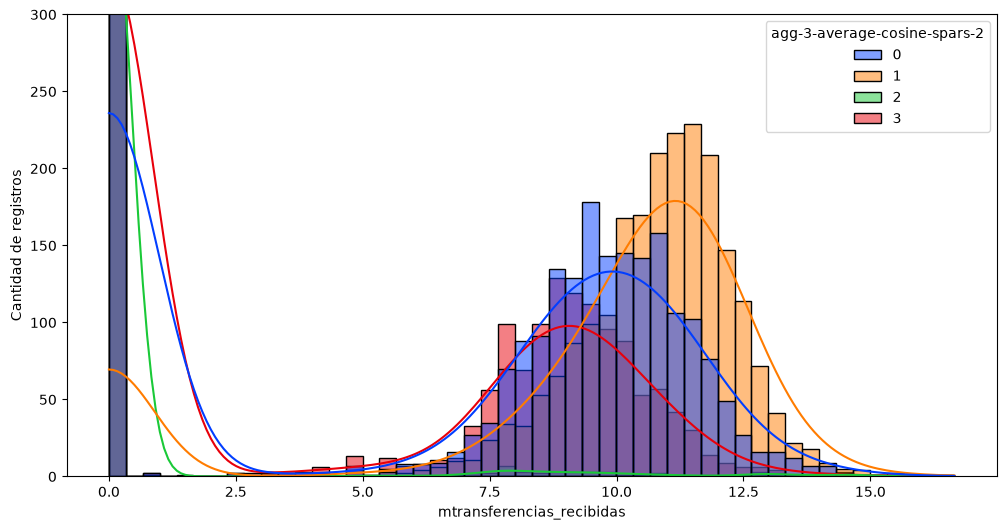

In [30]:
variable = "mtransferencias_recibidas"
columna_cluster = "agg-3-average-cosine-spars-2"

df_plot = df_baja_h.copy()

df_plot["valor_log"] = (
    np.sign(df_plot[variable])
    * np.log1p(np.abs(df_plot[variable]))
)

plt.figure(figsize=(12, 6))

sns.histplot(
    data=df_plot,
    x='valor_log',
    hue=columna_cluster,
    bins=50,
    stat="count",
    multiple="layer",
    alpha=0.50,
    kde=True,
    common_norm=False,
    palette='bright'
)
plt.ylim(0, 300)
plt.xlabel(variable)
plt.ylabel("Cantidad de registros")

plt.show()

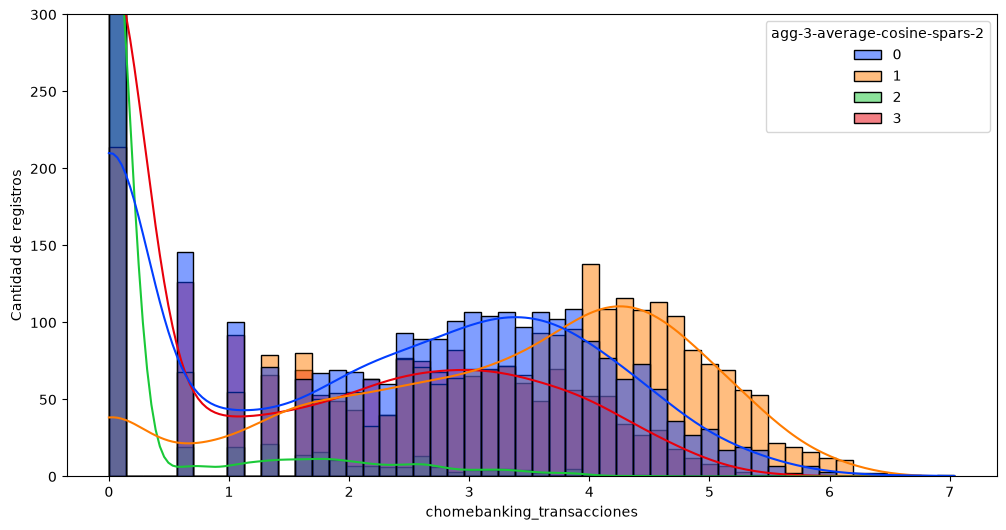

In [31]:
variable = "chomebanking_transacciones"
columna_cluster = "agg-3-average-cosine-spars-2"

df_baja_h = df_baja.copy()

df_plot["valor_log"] = (
    np.sign(df_plot[variable])
    * np.log1p(np.abs(df_plot[variable]))
)

plt.figure(figsize=(12, 6))

sns.histplot(
    data=df_plot,
    x='valor_log',
    hue=columna_cluster,
    bins=50,
    stat="count",
    multiple="layer",
    alpha=0.50,
    kde=True,
    common_norm=False,
    palette='bright'
)
plt.ylim(0, 300)
plt.xlabel(variable)
plt.ylabel("Cantidad de registros")

plt.show()

In [34]:
import importlib
import funciones.graficos_clusters_pdf as graficos_clusters_pdf
import funciones.distribucion_clusters_pdf as distribucion_clusters_pdf

importlib.reload(graficos_clusters_pdf)
importlib.reload(distribucion_clusters_pdf)

generar_pdf_clusters = graficos_clusters_pdf.generar_pdf_clusters

In [40]:
columna_cluster = 'agg-3-average-cosine-spars-2'
file_name = f'graficos-{columna_cluster}-sobre-consolidado-resumen.pdf'
output_file = os.path.join( os.getcwd(), 'graficos_clusters', file_name)
generar_pdf_clusters(
    df_variables=df_resumen,
    df_baja=df_baja,
    columna_cluster=columna_cluster,
    archivo_salida=output_file,
    banda="ic95",
    data_dict=DATA_DICT_URL,
    diccionario_consolidaciones=diccionario_consolidaciones
)

PosixPath('/home/marco/code/DMEyF/dmeyf2026/mis_pruebas/graficos_clusters/graficos-agg-3-average-cosine-spars-2-sobre-consolidado-resumen.pdf')

In [35]:

columna_cluster = 'k-mean-6-spars-8'
file_name = f'distribucion-{columna_cluster}-sobre-consolidado-resumen3.pdf'
output_file = os.path.join( os.getcwd(), 'graficos_clusters', file_name)

distribucion_clusters_pdf.generar_pdf_distribuciones_clusters(
    df_variables=df_resumen,
    df_baja=df_baja,
    columna_cluster=columna_cluster,
    archivo_salida=output_file,
    data_dict=DATA_DICT_URL,
    diccionario_consolidaciones=diccionario_consolidaciones
)

PosixPath('/home/marco/code/DMEyF/dmeyf2026/mis_pruebas/graficos_clusters/distribucion-k-mean-6-spars-8-sobre-consolidado-resumen3.pdf')